<a href="https://colab.research.google.com/github/Ranesshtallapelly/Data-analysis-python/blob/main/daup_week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

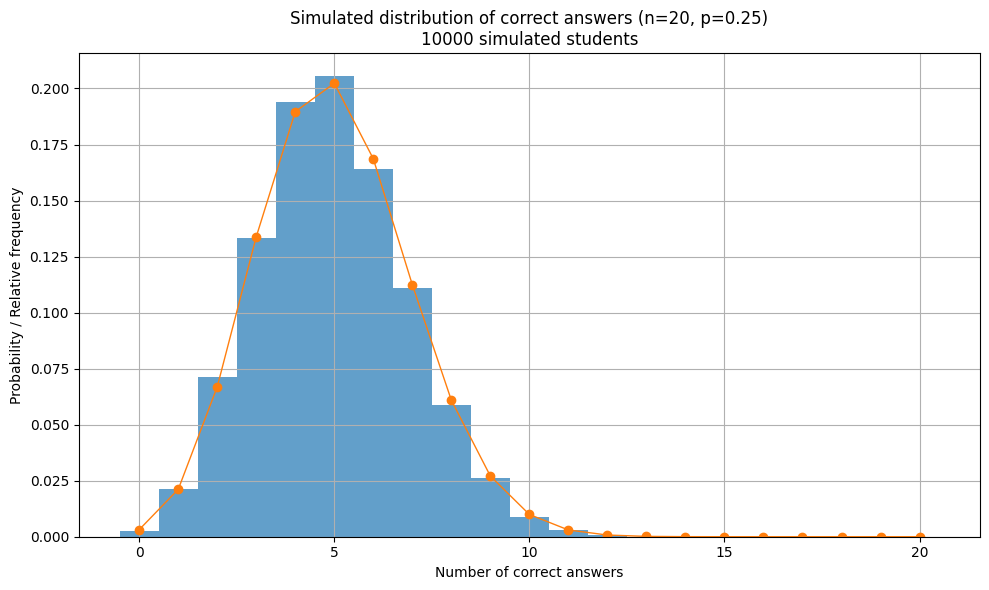

Analytical results for Binomial(n=20, p=0.25):
Mean = n*p = 5.0000
Variance = n*p*(1-p) = 3.7500
Standard deviation = sqrt(variance) = 1.9365
Most likely number of correct answers (mode) = floor((n+1)p) = 5

Exact probability computations:
P(X >= 10) = 0.01386442 (1.386442%)
P(X < 5)  = 0.41484150 (41.484150%)
P(5 <= X <= 8) = 0.54423333 (54.423333%)

Simulation summary (first 8 rows):
 student_id  correct_by_guessing
          1                    4
          2                    8
          3                    6
          4                    5
          5                    3
          6                    3
          7                    2
          8                    7

Frequency table from simulation (top rows):
 correct_answers  count  relative_freq
               0     27         0.0027
               1    215         0.0215
               2    711         0.0711
               3   1332         0.1332
               4   1939         0.1939
               5   2055         0.2

In [3]:
# binomial_analysis.py
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from collections import Counter
import os

# Parameters
n = 20
p = 0.25

# Analytical values
mean_analytic = n * p
var_analytic = n * p * (1 - p)
std_analytic = math.sqrt(var_analytic)

# Mode for binomial: floor((n+1)*p)
mode_binomial = math.floor((n + 1) * p)

# Function to compute exact binomial pmf using math.comb
def binom_pmf(k, n, p):
    return math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

# Probabilities required
prob_ge_10 = sum(binom_pmf(k, n, p) for k in range(10, n + 1))
prob_lt_5 = sum(binom_pmf(k, n, p) for k in range(0, 5))
prob_5_to_8 = sum(binom_pmf(k, n, p) for k in range(5, 9))

# Create simulated dataset
np.random.seed(42)
sim_N = 10000  # number of simulated students
sim_scores = np.random.binomial(n, p, size=sim_N)

df = pd.DataFrame({
    "student_id": np.arange(1, sim_N + 1),
    "correct_by_guessing": sim_scores
})

# Ensure the output directory exists
output_dir = "/mnt/data"
os.makedirs(output_dir, exist_ok=True)

# Save dataset to CSV
csv_path = os.path.join(output_dir, "binomial_dataset.csv")
df.to_csv(csv_path, index=False)

# Frequency table from simulation
freq = Counter(sim_scores)
freq_df = pd.DataFrame(sorted(freq.items()), columns=["correct_answers", "count"])
freq_df["relative_freq"] = freq_df["count"] / sim_N

# Theoretical PMF for overlay
k_values = list(range(0, n + 1))
pmf_values = [binom_pmf(k, n, p) for k in k_values]

# Plot histogram and PMF overlay
plt.figure(figsize=(10,6))
plt.hist(sim_scores, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.7)
plt.plot(k_values, pmf_values, marker='o', linestyle='-', linewidth=1)
plt.title("Simulated distribution of correct answers (n=20, p=0.25)\n10000 simulated students")
plt.xlabel("Number of correct answers")
plt.ylabel("Probability / Relative frequency")
plt.grid(True)
plt.tight_layout()
plot_path = os.path.join(output_dir, "binomial_histogram.png")
plt.savefig(plot_path)
plt.show()

# Print summary results
print("Analytical results for Binomial(n=20, p=0.25):")
print(f"Mean = n*p = {mean_analytic:.4f}")
print(f"Variance = n*p*(1-p) = {var_analytic:.4f}")
print(f"Standard deviation = sqrt(variance) = {std_analytic:.4f}")
print(f"Most likely number of correct answers (mode) = floor((n+1)p) = {mode_binomial}")
print()
print("Exact probability computations:")
print(f"P(X >= 10) = {prob_ge_10:.8f} ({prob_ge_10*100:.6f}%)")
print(f"P(X < 5)  = {prob_lt_5:.8f} ({prob_lt_5*100:.6f}%)")
print(f"P(5 <= X <= 8) = {prob_5_to_8:.8f} ({prob_5_to_8*100:.6f}%)")
print()
print("Simulation summary (first 8 rows):")
print(df.head(8).to_string(index=False))
print()
print("Frequency table from simulation (top rows):")
print(freq_df.head(12).to_string(index=False))
print()
print(f"Dataset saved to: {csv_path}")
print(f"Histogram image saved to: {plot_path}")